# IEEE-CIS Fraud Detection EDA

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns

import os
print(os.listdir("../input/ieee-fraud-detection"))

['test_identity.csv', 'sample_submission.csv', 'train_identity.csv', 'train_transaction.csv', 'test_transaction.csv']


In [2]:
# setting up default plotting parameters
%matplotlib inline

plt.rcParams['figure.figsize'] = [20.0, 5.0]
plt.rcParams.update({'font.size': 22,})

sns.set_palette('viridis')
sns.set_style('white')
sns.set_context('talk', font_scale=0.8)

In [3]:
raw_transaction = pd.read_csv('../input/ieee-fraud-detection/train_transaction.csv')

print('train_transaction shape: ')
print(raw_transaction.shape)

raw_transaction.head()

train_transaction shape: 
(590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


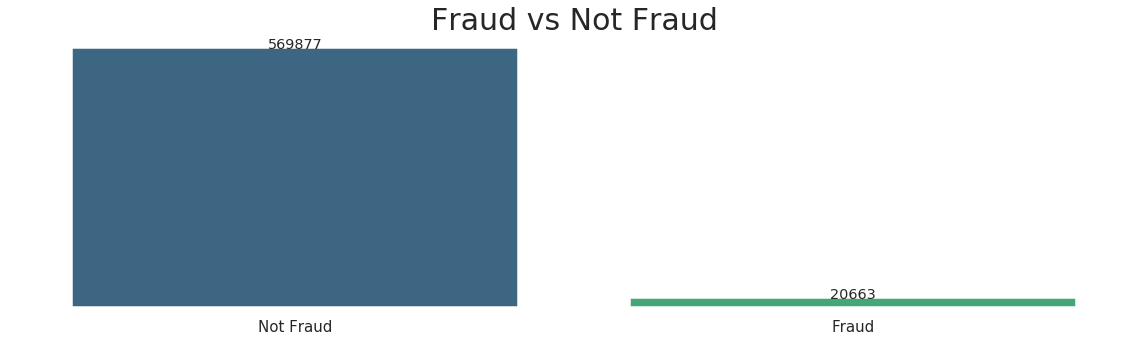

In [4]:
# using seaborns countplot to show distribution of questions in dataset
fig, ax = plt.subplots()
g = sns.countplot(raw_transaction.isFraud, palette='viridis')
g.set_xticklabels(['Not Fraud', 'Fraud'])
g.set_yticklabels([])

# function to show values on bars
def show_values_on_bars(axs):
    def _show_on_single_plot(ax):        
        for p in ax.patches:
            _x = p.get_x() + p.get_width() / 2
            _y = p.get_y() + p.get_height()
            value = '{:.0f}'.format(p.get_height())
            ax.text(_x, _y, value, ha="center") 

    if isinstance(axs, np.ndarray):
        for idx, ax in np.ndenumerate(axs):
            _show_on_single_plot(ax)
    else:
        _show_on_single_plot(axs)
show_values_on_bars(ax)

sns.despine(left=True, bottom=True)
plt.xlabel('')
plt.ylabel('')
plt.title('Fraud vs Not Fraud', fontsize=30)
plt.tick_params(axis='x', which='major', labelsize=15)
plt.show()

In [5]:
# print percentage of transactions where target == 1
(len(raw_transaction.loc[raw_transaction.isFraud==1])) / (len(raw_transaction.loc[raw_transaction.isFraud == 0])) * 100

3.625870143908247

Here we can see we have an imbalanced dataset with only 3.63% of transactions belonging to the target class Fraud.

In [6]:
#checking for missing values

# from https://github.com/WillKoehrsen/machine-learning-project-walkthrough/blob/master/Machine%20Learning%20Project%20Part%201.ipynb# from  
# Function to calculate missing values by column# Funct 
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [7]:
missing_values_table(raw_transaction).head(10)

Your selected dataframe has 394 columns.
There are 374 columns that have missing values.


,Missing Values,% of Total Values
dist2,552913,93.6
D7,551623,93.4
D13,528588,89.5
D14,528353,89.5
D12,525823,89.0
D6,517353,87.6
D9,515614,87.3
D8,515614,87.3
V157,508595,86.1
V163,508595,86.1


Here we see that we have a significant amount of missing data that will have to be dealt with.

In [8]:
# info method to get quick description of the data
raw_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


In [9]:
# summary of numerical attributes
raw_transaction.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,0.000000,0.000000,25.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,55.000000,160000.000000,160000.000000,160000.000000,55125.000000,55125.00000,55125.000000,104060.000000,104060.000000,104060.000000


### Transaction Features

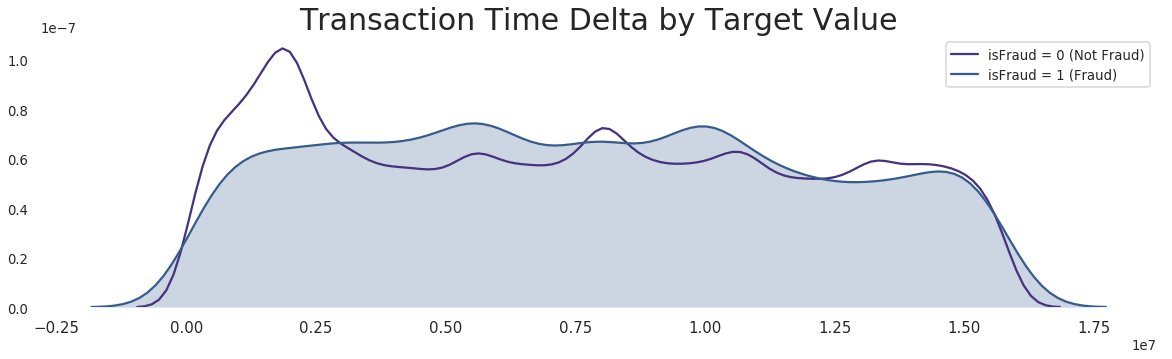

In [10]:
sns.kdeplot(raw_transaction.loc[raw_transaction['isFraud'] == 0,'TransactionDT'], label='isFraud = 0 (Not Fraud)')
sns.kdeplot(raw_transaction.loc[raw_transaction['isFraud'] == 1,'TransactionDT'], label='isFraud = 1 (Fraud)', shade=True)

sns.despine(left=True, bottom=True)
plt.xlabel('')
plt.ylabel('')
plt.title('Transaction Time Delta by Target Value', fontsize=30)
plt.tick_params(axis='x', which='major', labelsize=15)
plt.show()

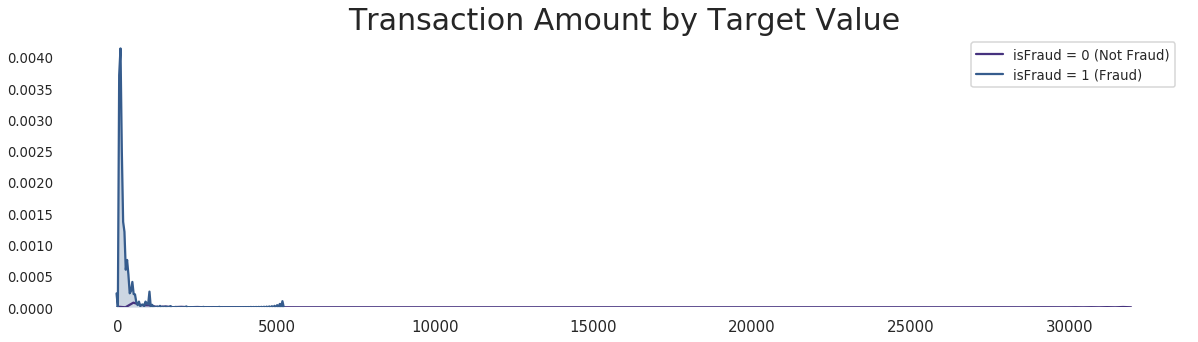

In [11]:
sns.kdeplot(raw_transaction.loc[raw_transaction['isFraud'] == 0,'TransactionAmt'], label='isFraud = 0 (Not Fraud)')
sns.kdeplot(raw_transaction.loc[raw_transaction['isFraud'] == 1,'TransactionAmt'], label='isFraud = 1 (Fraud)', shade=True)

sns.despine(left=True, bottom=True)
plt.xlabel('')
plt.ylabel('')
plt.title('Transaction Amount by Target Value', fontsize=30)
plt.tick_params(axis='x', which='major', labelsize=15)
plt.show()

We see there is a very long tail and most data is clustered to the left.  Let's use a log transformation to see if we can make the graph easier to visualize.

In [12]:
# creating new dataframe for manipulated features
transaction = raw_transaction[['isFraud']].copy()
transaction['log_transaction_amt'] = np.log(raw_transaction.TransactionAmt)

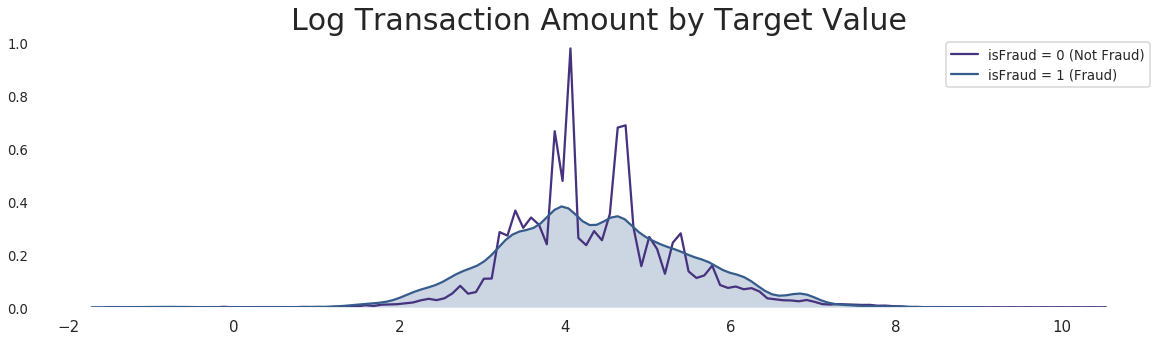

In [13]:
sns.kdeplot(transaction.loc[transaction['isFraud'] == 0,'log_transaction_amt'], label='isFraud = 0 (Not Fraud)')
sns.kdeplot(transaction.loc[transaction['isFraud'] == 1,'log_transaction_amt'], label='isFraud = 1 (Fraud)', shade=True)

sns.despine(left=True, bottom=True)
plt.xlabel('')
plt.ylabel('')
plt.title('Log Transaction Amount by Target Value', fontsize=30)
plt.tick_params(axis='x', which='major', labelsize=15)
plt.show()

Much better.  There definitely appear to be differences in transaction amount for fraud and not fraud transactions.

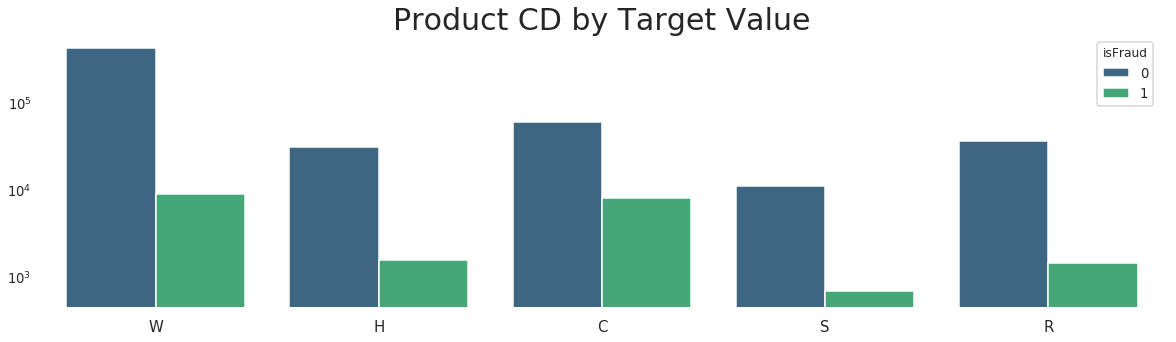

In [14]:
fig, ax = plt.subplots()
ax.set(yscale='log')
sns.countplot(x='ProductCD', hue='isFraud', data=raw_transaction, palette='viridis')

sns.despine(left=True, bottom=True)
plt.xlabel('')
plt.ylabel('')
plt.title('Product CD by Target Value', fontsize=30)
plt.tick_params(axis='x', which='major', labelsize=15)
plt.show()

### Card Features (Categorical)

In [15]:
# create card dataset and drop null values
card = raw_transaction[['isFraud', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6']].copy()
card = card.dropna()

In [16]:
# checking unique values
for i in card:
    print ("Unique Values",i, " = ",card[i].nunique())

Unique Values isFraud  =  2
Unique Values card1  =  13168
Unique Values card2  =  499
Unique Values card3  =  107
Unique Values card4  =  4
Unique Values card5  =  117
Unique Values card6  =  4


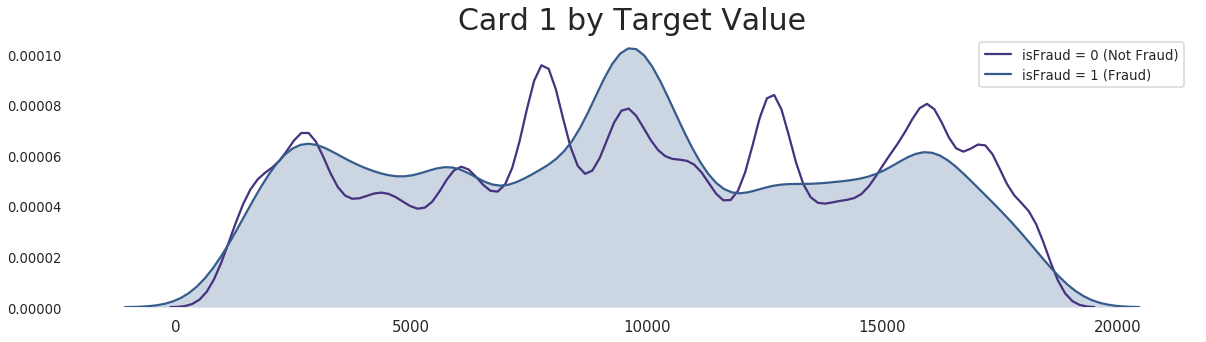

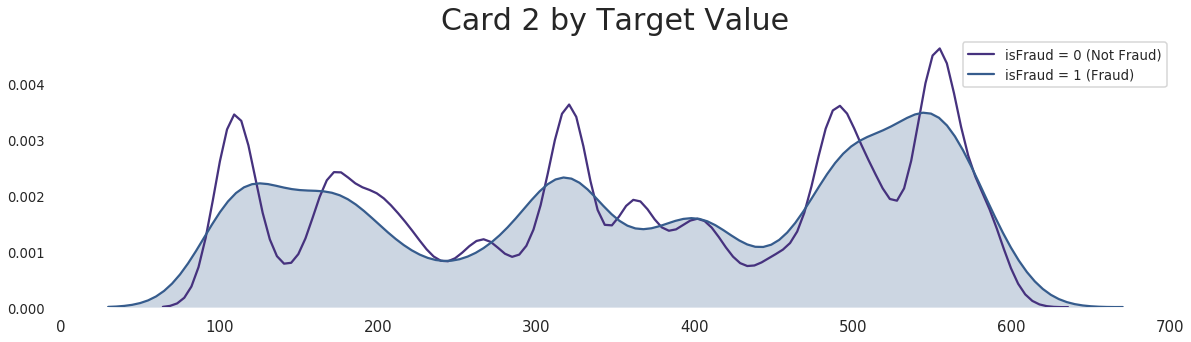

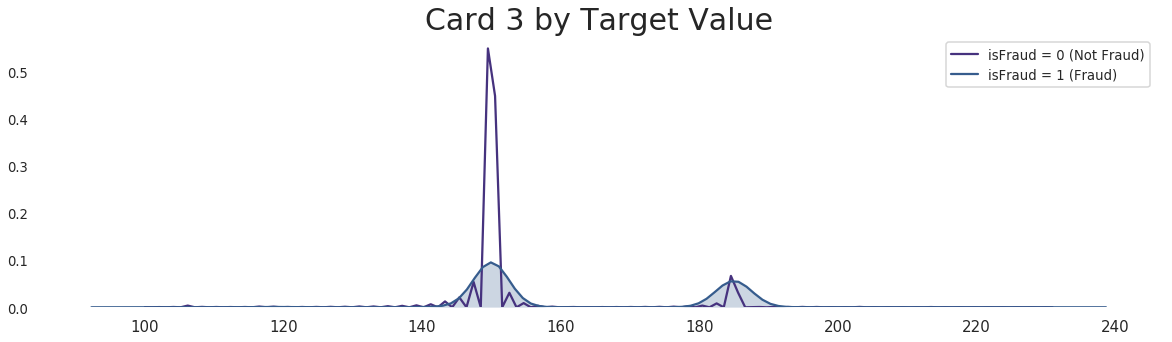

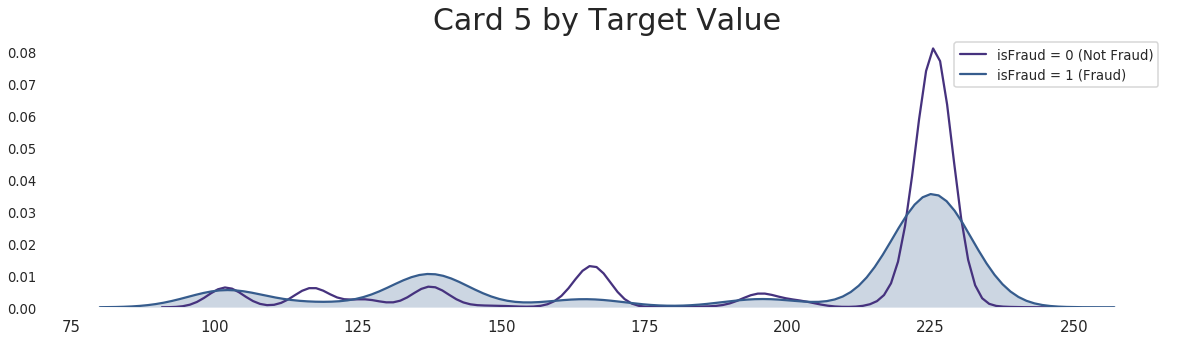

In [17]:
# plotting card features
sns.kdeplot(card.loc[card['isFraud'] == 0,'card1'], label='isFraud = 0 (Not Fraud)')
sns.kdeplot(card.loc[card['isFraud'] == 1,'card1'], label='isFraud = 1 (Fraud)', shade=True)

sns.despine(left=True, bottom=True)
plt.xlabel('')
plt.ylabel('')
plt.title('Card 1 by Target Value', fontsize=30)
plt.tick_params(axis='x', which='major', labelsize=15)
plt.show()


sns.kdeplot(card.loc[card['isFraud'] == 0,'card2'], label='isFraud = 0 (Not Fraud)')
sns.kdeplot(card.loc[card['isFraud'] == 1,'card2'], label='isFraud = 1 (Fraud)', shade=True)

sns.despine(left=True, bottom=True)
plt.xlabel('')
plt.ylabel('')
plt.title('Card 2 by Target Value', fontsize=30)
plt.tick_params(axis='x', which='major', labelsize=15)
plt.show()

sns.kdeplot(card.loc[card['isFraud'] == 0,'card3'], label='isFraud = 0 (Not Fraud)')
sns.kdeplot(card.loc[card['isFraud'] == 1,'card3'], label='isFraud = 1 (Fraud)', shade=True)

sns.despine(left=True, bottom=True)
plt.xlabel('')
plt.ylabel('')
plt.title('Card 3 by Target Value', fontsize=30)
plt.tick_params(axis='x', which='major', labelsize=15)
plt.show()

sns.kdeplot(card.loc[card['isFraud'] == 0,'card5'], label='isFraud = 0 (Not Fraud)')
sns.kdeplot(card.loc[card['isFraud'] == 1,'card5'], label='isFraud = 1 (Fraud)', shade=True)

sns.despine(left=True, bottom=True)
plt.xlabel('')
plt.ylabel('')
plt.title('Card 5 by Target Value', fontsize=30)
plt.tick_params(axis='x', which='major', labelsize=15)
plt.show()

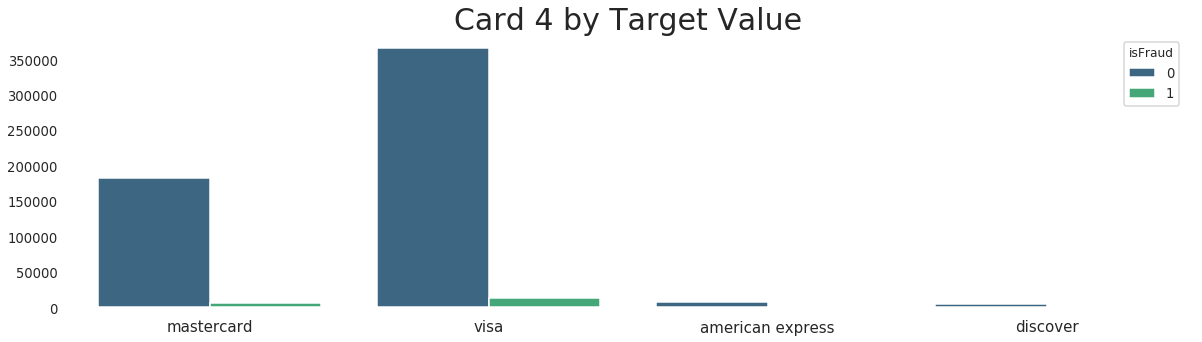

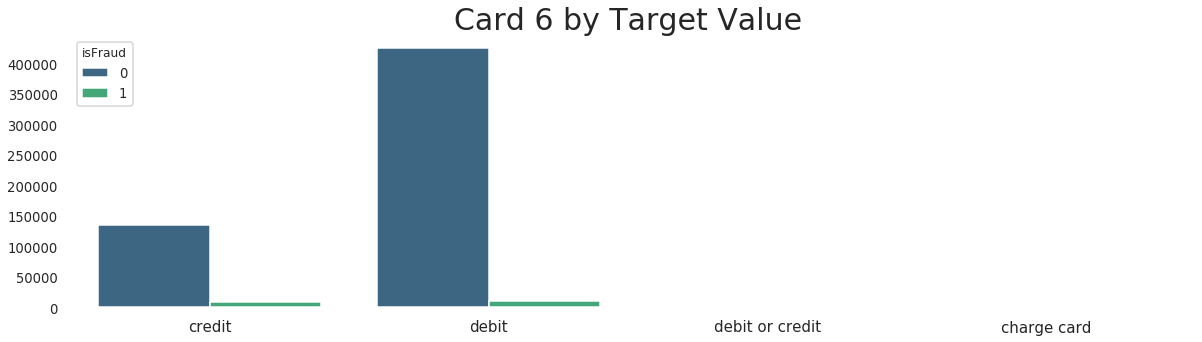

In [18]:
sns.countplot(x='card4', hue='isFraud', data=card, palette='viridis')

sns.despine(left=True, bottom=True)
plt.xlabel('')
plt.ylabel('')
plt.title('Card 4 by Target Value', fontsize=30)
plt.tick_params(axis='x', which='major', labelsize=15)
plt.show()

sns.countplot(x='card6', hue='isFraud', data=card, palette='viridis')

sns.despine(left=True, bottom=True)
plt.xlabel('')
plt.ylabel('')
plt.title('Card 6 by Target Value', fontsize=30)
plt.tick_params(axis='x', which='major', labelsize=15)
plt.show()

### E-Mail Features

In [19]:
# check unique and missing values for email features
email = raw_transaction[['isFraud','P_emaildomain', 'R_emaildomain']].copy()
for i in email:
    print('Unique Values', i, '=', email[i].nunique())

missing_values_table(email)

Unique Values isFraud = 2
Unique Values P_emaildomain = 59
Unique Values R_emaildomain = 60
Your selected dataframe has 3 columns.
There are 2 columns that have missing values.


,Missing Values,% of Total Values
R_emaildomain,453249,76.8
P_emaildomain,94456,16.0


In [20]:
# fill missing values
email.P_emaildomain.fillna('none', inplace=True)
email.R_emaildomain.fillna('none', inplace=True)

# check unique and missing values for email features
for i in email:
    print('Unique Values', i, '=', email[i].nunique())

missing_values_table(email)

Unique Values isFraud = 2
Unique Values P_emaildomain = 60
Unique Values R_emaildomain = 61
Your selected dataframe has 3 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


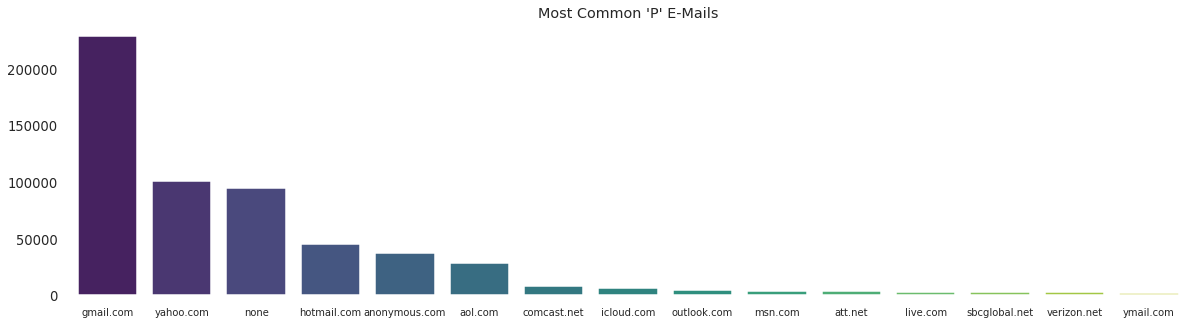

In [21]:
from collections import Counter

p_email = Counter(email.P_emaildomain)
common_email = [e[0] for e in p_email.most_common(15)]
common_counts = [e[1] for e in p_email.most_common(15)]

sns.barplot(common_email, common_counts, palette='viridis')
sns.despine(left=True, bottom=True)
plt.title("Most Common 'P' E-Mails")
plt.tick_params(axis='x', which='major', labelsize=10)
plt.show()

In [22]:
# keep only most common emails and set all to other
# use isin to check membership in list, ~ to negate, .loc to modify series in place
email.loc[~email['P_emaildomain'].isin(common_email), 'P_emaildomain'] = 'other'
email.P_emaildomain.nunique()

16

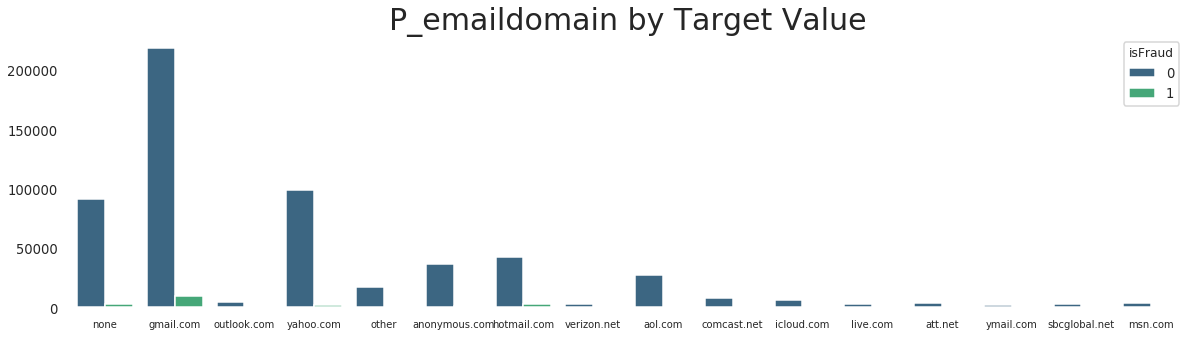

In [23]:
sns.countplot(x='P_emaildomain', hue='isFraud', data=email, palette='viridis')

sns.despine(left=True, bottom=True)
plt.xlabel('')
plt.ylabel('')
plt.title('P_emaildomain by Target Value', fontsize=30)
plt.tick_params(axis='x', which='major', labelsize=10)
plt.show()

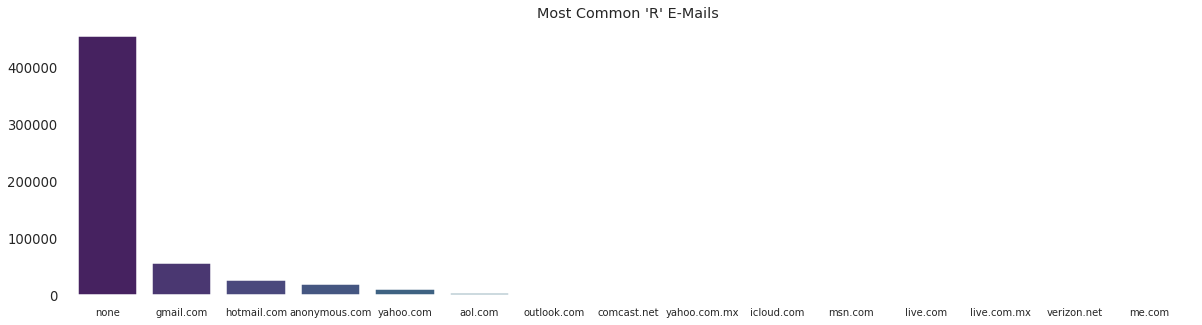

In [24]:
r_email = Counter(email.R_emaildomain)
common_email = [e[0] for e in r_email.most_common(15)]
common_counts = [e[1] for e in r_email.most_common(15)]

sns.barplot(common_email, common_counts, palette='viridis')
sns.despine(left=True, bottom=True)
plt.title("Most Common 'R' E-Mails")
plt.tick_params(axis='x', which='major', labelsize=10)
plt.show()

In [25]:
# keep only most common emails and set all to other
# use isin to check membership in list, ~ to negate, .loc to modify series in place
email.loc[~email['R_emaildomain'].isin(common_email), 'R_emaildomain'] = 'other'
email.R_emaildomain.nunique()

16

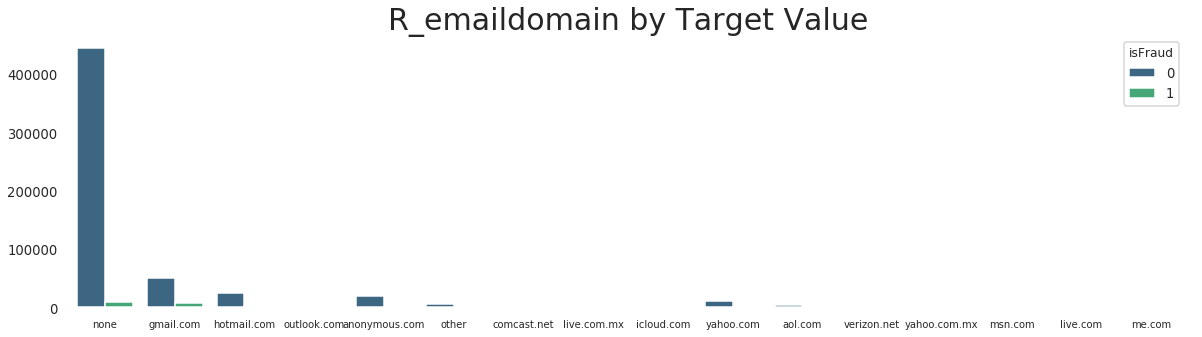

In [26]:
sns.countplot(x='R_emaildomain', hue='isFraud', data=email, palette='viridis')

sns.despine(left=True, bottom=True)
plt.xlabel('')
plt.ylabel('')
plt.title('R_emaildomain by Target Value', fontsize=30)
plt.tick_params(axis='x', which='major', labelsize=10)
plt.show()